# Reach direction and velocity tuning in monkey motor cortex

**Dataset:** [DANDI:000128](https://dandiarchive.org/dandiset/000128) — *MC_Maze*, the
Neural Latents Benchmark release of the Churchland / Kaufman / Shenoy maze-reaching
recordings. We use the full training session from monkey Jenkins
(`sub-Jenkins/sub-Jenkins_ses-full_desc-train_behavior+ecephys.nwb`, recorded 2009-09-25):
2295 successful reaches, 182 sorted units from two Utah arrays implanted in primary motor
cortex (M1) and dorsal premotor cortex (PMd), and hand position and velocity sampled at
1 kHz.

**What we are demonstrating.** Two classical claims about motor cortex, on real data:

1. **Direction tuning** (Georgopoulos et al., 1982): a single unit's firing rate during a
   reach is an approximately cosine function of the direction of the reach, so each unit
   has a *preferred direction*.
2. **Velocity tuning** (Schwartz, Moran and colleagues): the relevant variable is not the
   direction alone but the full hand *velocity vector*. The cosine tuning curve keeps its
   preferred direction but grows in amplitude as the hand moves faster, which is what a
   linear dependence on velocity, `rate ≈ b₀ + b·v`, predicts.

**How we test them.** Three converging analyses, all in Pynapple:

* a **trial-based** analysis that measures each unit's tuning curve over reach direction
  and asks whether the amplitude of that curve grows with movement speed;
* a **continuous** analysis over the whole session in 20 ms bins, which maps firing rate
  directly onto the two-dimensional velocity plane and measures how far neural activity
  leads the hand;
* a **model comparison and decoding** step, with Poisson GLMs fitted in NeMoS and a
  population decoder that reconstructs hand velocity from the 182 units.

The maze task is well suited to this because the barriers force curved reaches, so the
hand direction is not simply a function of which of a few targets was cued. We always
define direction and speed from the *measured* hand velocity, never from the target.

## 1. Setup

In [1]:
%matplotlib inline
import os
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pynapple as nap
from scipy import stats
from tqdm.auto import tqdm

DANDISET_ID = "000128"
ASSET_PATH = "sub-Jenkins/sub-Jenkins_ses-full_desc-train_behavior+ecephys.nwb"
REMFILE_CACHE = "/tmp/remfile_cache"
LOCAL_CACHE = "mc_maze_cache.pkl"

# Analysis windows, in seconds relative to movement onset.
KIN_WIN = (0.00, 0.25)      # window over which the reach direction / speed is measured
NEURAL_WIN = (-0.10, 0.15)  # spike-count window, shifted 100 ms earlier (motor cortex leads)
BIN = 0.02                  # bin size for the continuous analysis

AREA_COLORS = {"M1": "#1b6ca8", "PMd": "#d1495b"}


def tidy_polar_r(ax, rlabel_pos, n=3):
    """Sparse, fixed radial ticks with a white backing box.

    Polar axes otherwise place five or six radial labels along a spoke that runs straight
    through the data, which is unreadable. Fixing the locator is what makes the setting
    stick: with the default locator the ticks are recomputed at draw time and any styling
    applied to the label objects here is thrown away.
    """
    from matplotlib.ticker import MaxNLocator

    ax.set_rlabel_position(rlabel_pos)
    rmax = ax.get_rmax()
    ticks = [t for t in MaxNLocator(nbins=n).tick_values(0, rmax) if 0 < t <= rmax]
    ax.set_yticks(ticks)
    ax.set_yticklabels(["%g" % t for t in ticks], fontsize=7,
                       bbox=dict(fc="w", ec="none", alpha=0.75, pad=0.5))
rng = np.random.default_rng(0)
plt.rcParams["figure.dpi"] = 110

## 2. Streaming the NWB file from DANDI

The asset is 0.69 GB, so we stream it from the DANDI S3 bucket with `remfile` and a local
disk cache rather than downloading it. The arrays we actually need (kinematics, spike
times, the trial table) are then pickled locally so that re-running the notebook is fast.

Two quirks of this particular file are worth recording, because they affect how units are
assigned to a brain area:

* `units/electrodes` is a `DynamicTableRegion`, but PyNWB does not resolve it correctly
  here, so we read the row indices straight out of HDF5.
* The stored indices are *within-array* channel numbers (0–95) rather than global
  electrode rows, so the sequence restarts when the unit list crosses from one array to
  the other. We recover the global row by detecting that single reset. Electrode rows
  0–95 are PMd and 96–191 are M1, so the first block of units is PMd and the second is M1.
  The area labels are used only for the M1-versus-PMd comparisons below; none of the
  tuning conclusions depend on them.

In [2]:
def download_payload():
    """Stream the NWB file and pull out the arrays this analysis needs."""
    import h5py
    import remfile
    from pynwb import NWBHDF5IO
    from dandi.dandiapi import DandiAPIClient

    with DandiAPIClient() as client:
        asset = client.get_dandiset(DANDISET_ID, "draft").get_asset_by_path(ASSET_PATH)
        url = asset.get_content_url(follow_redirects=1, strip_query=True)
    print("streaming", url)

    os.makedirs(REMFILE_CACHE, exist_ok=True)
    rf = remfile.File(url, disk_cache=remfile.DiskCache(REMFILE_CACHE))
    h5 = h5py.File(rf, "r")
    nwbfile = NWBHDF5IO(file=h5, load_namespaces=True).read()
    print(nwbfile.session_description)

    beh = nwbfile.processing["behavior"]
    hv, hp = beh["hand_vel"], beh["hand_pos"]
    print("reading kinematics ...")
    t_kin = np.asarray(hv.timestamps[:], dtype=np.float64)
    hand_vel = np.asarray(hv.data[:], dtype=np.float64) * hv.conversion   # mm/s -> m/s
    hand_pos = np.asarray(hp.data[:], dtype=np.float64) * hp.conversion   # mm   -> m

    print("reading units ...")
    units = nwbfile.units
    spike_times = [np.asarray(s, dtype=np.float64) for s in units["spike_times"][:]]
    obs = np.asarray(units["obs_intervals"][0])   # identical across units in this file
    elec = nwbfile.electrodes.to_dataframe()

    chan = np.asarray(h5["units/electrodes"][:], dtype=int)
    resets = np.flatnonzero(np.diff(chan) < 0)
    assert len(resets) == 1, f"expected one array boundary, found {resets}"
    n_per_array = len(elec) // 2
    assert chan.max() < n_per_array
    array_id = np.zeros(len(chan), dtype=int)
    array_id[resets[0] + 1:] = 1
    area = elec["location"].values[array_id * n_per_array + chan].astype(str)

    print("reading trials ...")
    trials = nwbfile.trials.to_dataframe()
    tgt = np.full((len(trials), 2), np.nan)
    for i, (tp, ai) in enumerate(zip(trials["target_pos"].values,
                                     trials["active_target"].values)):
        tp = np.atleast_2d(np.asarray(tp))
        if 0 <= ai < len(tp):
            tgt[i] = tp[ai]
    trials = trials.drop(columns=["target_pos", "barrier_pos"])
    trials["target_x"], trials["target_y"] = tgt[:, 0] * 1e-3, tgt[:, 1] * 1e-3

    return dict(t_kin=t_kin, hand_vel=hand_vel, hand_pos=hand_pos,
                spike_times=spike_times, obs_intervals=obs, area=area,
                trials=trials, session_description=nwbfile.session_description)


def load_pynapple():
    """Load the session as Pynapple objects, using the local pickle cache if present."""
    if os.path.exists(LOCAL_CACHE):
        with open(LOCAL_CACHE, "rb") as fh:
            p = pickle.load(fh)
    else:
        p = download_payload()
        with open(LOCAL_CACHE, "wb") as fh:
            pickle.dump(p, fh, protocol=4)

    obs_ep = nap.IntervalSet(start=p["obs_intervals"][:, 0], end=p["obs_intervals"][:, 1])
    units = nap.TsGroup({i: nap.Ts(t=st) for i, st in enumerate(p["spike_times"])},
                        time_support=obs_ep, metadata={"area": p["area"]})
    vel = nap.TsdFrame(t=p["t_kin"], d=p["hand_vel"], columns=["vx", "vy"],
                       time_support=obs_ep)
    pos = nap.TsdFrame(t=p["t_kin"], d=p["hand_pos"], columns=["x", "y"],
                       time_support=obs_ep)
    speed = nap.Tsd(t=vel.t, d=np.linalg.norm(vel.values, axis=1), time_support=obs_ep)
    return dict(units=units, vel=vel, pos=pos, speed=speed, obs_ep=obs_ep,
                trials=p["trials"], meta=p)


data = load_pynapple()
units, vel, pos, speed, obs_ep = (data["units"], data["vel"], data["pos"],
                                  data["speed"], data["obs_ep"])
area = units.get_info("area").values.astype(str)
print(units)

  Index      rate  area
-------  --------  ------
      0   0.85331  PMd
      1   0.95772  PMd
      2   0.62791  PMd
      3   0.22687  PMd
      4   1.78284  PMd
      5   0.58004  PMd
      6   1.77491  PMd
      7   1.84907  PMd
      8   2.26581  PMd
      9   0.16124  PMd
     10   0.27342  PMd
     11   1.98431  PMd
     12   1.2564   PMd
     13  10.0577   PMd
     14   1.18063  PMd
     15   1.52263  PMd
     16   1.22615  PMd
     17   6.94575  PMd
     18   0.54421  PMd
     19   0.7119   PMd
     20   0.21909  PMd
     21   0.66124  PMd
     22   1.75626  PMd
     23   3.25026  PMd
     24   0.57651  PMd
     25   0.46564  PMd
     26   8.97529  PMd
     27   3.10841  PMd
     28   0.55243  PMd
     29   0.15771  PMd
     30   1.08401  PMd
     31   0.72292  PMd
     32   0.74597  PMd
     33   5.43222  PMd
     34  10.8738   PMd
     35   0.89179  PMd
     36   1.8799   PMd
     37   1.23526  PMd
     38   1.15611  PMd
     39   4.07171  PMd
     40   2.8761   PMd
     41

### Inspecting each stream before analysing it

`obs_intervals` marks the windows in which spikes were actually recorded; the file does
not cover the inter-trial gaps, so everything below is restricted to those intervals.

In [3]:
print("units      : %d (%d M1, %d PMd), median rate %.2f Hz, range %.2f-%.2f Hz"
      % (len(units), (area == "M1").sum(), (area == "PMd").sum(),
         np.median(units.rate), units.rate.min(), units.rate.max()))
print("kinematics : %d samples at %.0f Hz, no NaNs: %s"
      % (len(vel), 1 / np.median(np.diff(vel.t)),
         not np.isnan(vel.values).any() and not np.isnan(pos.values).any()))
print("observed   : %d intervals, %.0f s total (session spans %.0f s)"
      % (len(obs_ep), obs_ep.tot_length(), obs_ep.end[-1] - obs_ep.start[0]))
print("trials     : %d, columns: %s" % (len(data["trials"]),
                                        ", ".join(data["trials"].columns)))

units      : 182 (90 M1, 92 PMd), median rate 1.72 Hz, range 0.12-15.79 Hz
kinematics : 6809920 samples at 1000 Hz, no NaNs: True
observed   : 2295 intervals, 6810 s total (session spans 6952 s)
trials     : 2295, columns: start_time, stop_time, trial_type, trial_version, maze_id, success, target_on_time, go_cue_time, move_onset_time, rt, delay, num_targets, num_barriers, active_target, split, target_x, target_y


## 3. Building the trial table

For every trial we take the direction and the speed of the reach from the **measured**
hand velocity: the direction is the angle of the mean velocity vector over the first
250 ms of movement, and the speed is the mean instantaneous speed over the same window.
On maze trials the hand curves around the barriers, so this is not the same as the
direction to the target, and using the measured value is the honest choice.

In [4]:
def trial_table(data, min_speed=0.05):
    tr = data["trials"].copy()
    tk = data["pos"].t
    px, py = np.asarray(data["pos"]["x"].values), np.asarray(data["pos"]["y"].values)
    sp, vv = np.asarray(data["speed"].values), np.asarray(data["vel"].values)

    onset = tr["move_onset_time"].values
    i0 = np.clip(np.searchsorted(tk, onset + KIN_WIN[0]), 0, len(tk) - 1)
    i1 = np.clip(np.searchsorted(tk, onset + KIN_WIN[1]), 0, len(tk) - 1)

    mv = np.array([vv[a:b].mean(0) if b > a else [np.nan, np.nan]
                   for a, b in zip(i0, i1)])
    tr["mv_x"], tr["mv_y"] = mv[:, 0], mv[:, 1]
    tr["mv_dir"] = np.arctan2(mv[:, 1], mv[:, 0])
    tr["mv_speed"] = np.array([sp[a:b].mean() if b > a else np.nan
                               for a, b in zip(i0, i1)])
    tr["peak_speed"] = np.array([sp[a:b].max() if b > a else np.nan
                                 for a, b in zip(i0, i1)])
    tr["target_dir"] = np.arctan2(tr["target_y"] - py[i0], tr["target_x"] - px[i0])
    tr["straight"] = tr["num_barriers"].values == 0
    tr["use"] = (tr["success"].values & np.isfinite(tr["mv_dir"].values)
                 & (tr["peak_speed"].values > min_speed)
                 & (onset + 0.35 < data["obs_ep"].end[-1]))
    return tr


trials = trial_table(data)
use = trials[trials["use"]]
print("usable trials: %d of %d (%d with no barrier, %d maze)"
      % (len(use), len(trials), use["straight"].sum(), (~use["straight"]).sum()))
print("mean speed over 0-250 ms (5/50/95 pct, cm/s): %s"
      % (100 * np.percentile(use["mv_speed"], [5, 50, 95])).round(0))
print("peak speed (5/50/95 pct, cm/s)              : %s"
      % (100 * np.percentile(use["peak_speed"], [5, 50, 95])).round(0))
print("median |reach direction - target direction| : %.1f deg"
      % np.degrees(np.median(np.abs(np.angle(
          np.exp(1j * (use["mv_dir"] - use["target_dir"])))))))

usable trials: 2295 of 2295 (789 with no barrier, 1506 maze)
mean speed over 0-250 ms (5/50/95 pct, cm/s): [37. 52. 65.]
peak speed (5/50/95 pct, cm/s)              : [ 56.  80. 107.]
median |reach direction - target direction| : 17.1 deg


## 4. Figure 1 — raw data

Hand position, hand velocity, hand speed and the spike raster of all 182 units over eight
consecutive trials. Each reach is a single brisk velocity pulse lasting a few hundred
milliseconds, and the raster is visibly modulated around each one.

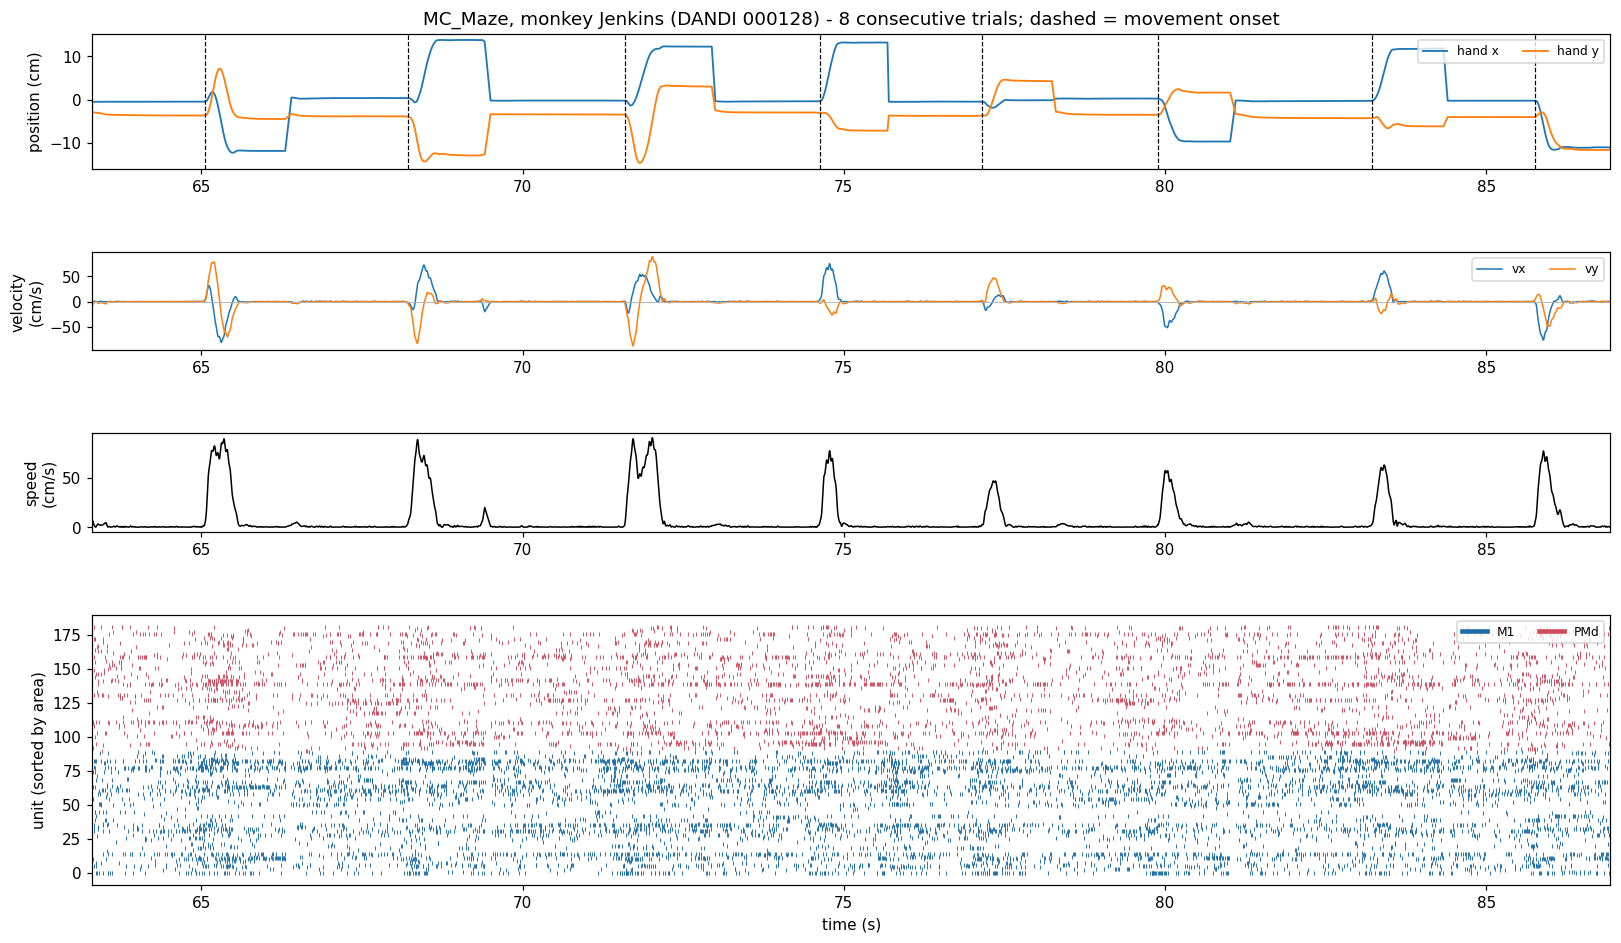

In [5]:
t0, t1 = use["start_time"].iloc[20], use["stop_time"].iloc[27]
win = nap.IntervalSet(start=t0, end=t1)

fig = plt.figure(figsize=(15, 9))
gs = fig.add_gridspec(4, 1, height_ratios=[1.1, 0.8, 0.8, 2.2], hspace=0.55,
                      left=0.06, right=0.98, top=0.93, bottom=0.07)

ax = fig.add_subplot(gs[0])
p = pos.restrict(win)
ax.plot(p.t, 100 * p["x"].values, lw=1.2, label="hand x")
ax.plot(p.t, 100 * p["y"].values, lw=1.2, label="hand y")
for _, r in use[(use.start_time >= t0) & (use.start_time < t1)].iterrows():
    ax.axvline(r["move_onset_time"], color="k", ls="--", lw=0.8)
ax.set_ylabel("position (cm)")
ax.legend(loc="upper right", fontsize=8, ncol=2)
ax.set_title("MC_Maze, monkey Jenkins (DANDI 000128) - 8 consecutive trials; "
             "dashed = movement onset")

ax = fig.add_subplot(gs[1])
v = vel.restrict(win)
ax.plot(v.t, 100 * v["vx"].values, lw=1.0, label="vx")
ax.plot(v.t, 100 * v["vy"].values, lw=1.0, label="vy")
ax.axhline(0, color="0.7", lw=0.6)
ax.set_ylabel("velocity\n(cm/s)")
ax.legend(loc="upper right", fontsize=8, ncol=2)

ax = fig.add_subplot(gs[2])
s = speed.restrict(win)
ax.plot(s.t, 100 * s.values, color="k", lw=1.0)
ax.set_ylabel("speed\n(cm/s)")

ax = fig.add_subplot(gs[3])
for row, j in enumerate(np.argsort(area)):
    st = units[list(units.keys())[j]].restrict(win).t
    ax.plot(st, np.full_like(st, row), "|", ms=2.5, color=AREA_COLORS[area[j]], mew=0.6)
ax.set_ylabel("unit (sorted by area)")
ax.set_xlabel("time (s)")
ax.legend(handles=[plt.Line2D([], [], color=c, lw=3, label=k)
                   for k, c in AREA_COLORS.items()], loc="upper right", fontsize=8, ncol=2)
for a in fig.axes:
    a.set_xlim(t0, t1)
fig.savefig("fig01_raw_data.png", dpi=130)

## 5. Figure 2 — the behaviour

Reaches cover the whole direction circle, peak speeds span roughly a two-fold range, and
the maze trials (red, right panel) depart from the straight line to the target while the
barrier-free trials (blue) follow it. That spread in both direction and speed is exactly
what the tuning analysis needs.

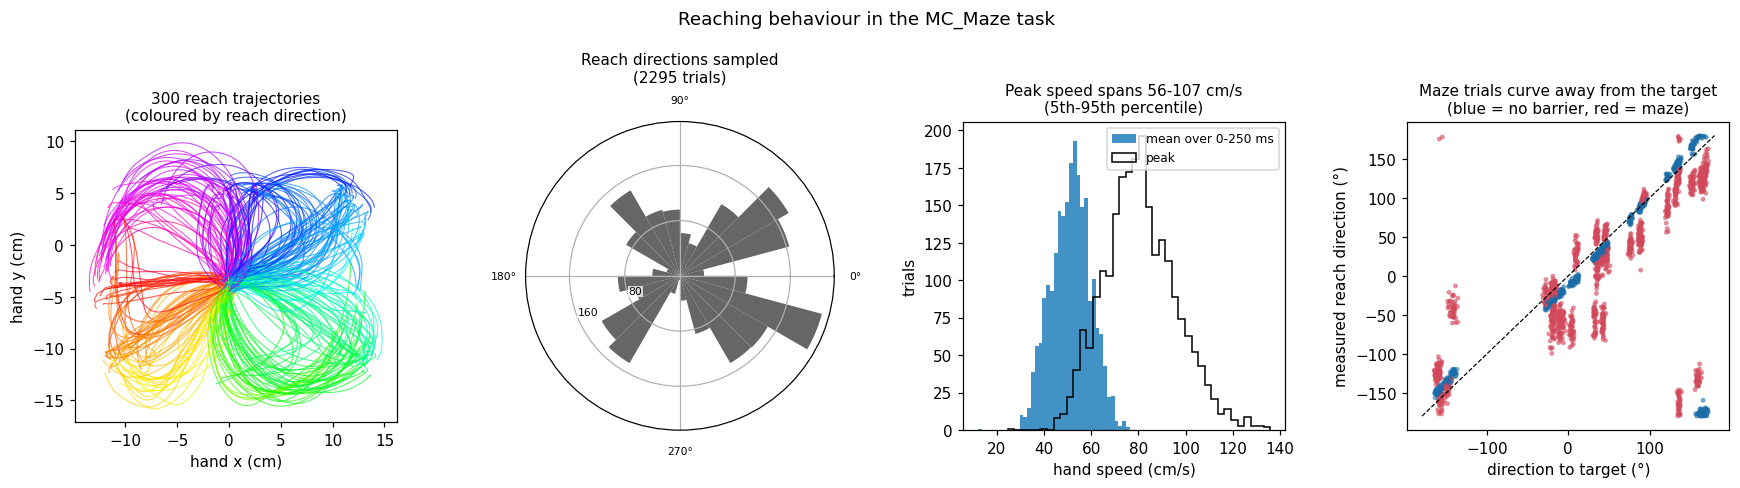

In [6]:
fig, axs = plt.subplots(1, 4, figsize=(16, 4.6))
fig.subplots_adjust(wspace=0.38, left=0.05, right=0.99, top=0.76, bottom=0.15)
hsv = plt.get_cmap("hsv")

ax = axs[0]
for _, r in use.sample(300, random_state=0).iterrows():
    seg = pos.restrict(nap.IntervalSet(start=r["move_onset_time"],
                                       end=r["move_onset_time"] + 0.4))
    ax.plot(100 * seg["x"].values, 100 * seg["y"].values,
            color=hsv((r["mv_dir"] + np.pi) / (2 * np.pi)), lw=0.7, alpha=0.7)
ax.set_aspect("equal")
ax.set_xlabel("hand x (cm)"); ax.set_ylabel("hand y (cm)")
ax.set_title("300 reach trajectories\n(coloured by reach direction)", fontsize=10)

ax = fig.add_subplot(1, 4, 2, projection="polar")
axs[1].remove()
h, e = np.histogram(use["mv_dir"], bins=np.linspace(-np.pi, np.pi, 25))
ax.bar(e[:-1] + np.diff(e) / 2, h, width=np.diff(e), color="0.4")
ax.set_title("Reach directions sampled\n(%d trials)" % len(use), fontsize=10, pad=26)
ax.tick_params(labelsize=7)
ax.set_xticks(np.radians([0, 90, 180, 270]))
tidy_polar_r(ax, 202)

ax = axs[2]
ax.hist(100 * use["mv_speed"], bins=40, color="#4292c6", label="mean over 0-250 ms")
ax.hist(100 * use["peak_speed"], bins=40, histtype="step", lw=1.8, color="k", label="peak")
ax.set_xlabel("hand speed (cm/s)"); ax.set_ylabel("trials")
ax.legend(fontsize=8)
ax.set_title("Peak speed spans %.0f-%.0f cm/s\n(5th-95th percentile)"
             % tuple(100 * np.percentile(use["peak_speed"], [5, 95])), fontsize=10)

ax = axs[3]
ax.scatter(np.degrees(use["target_dir"]), np.degrees(use["mv_dir"]),
           c=["#1b6ca8" if s else "#d1495b" for s in use["straight"]], s=5, alpha=0.5)
ax.plot([-180, 180], [-180, 180], "k--", lw=0.8)
ax.set_xlabel("direction to target (°)"); ax.set_ylabel("measured reach direction (°)")
ax.set_title("Maze trials curve away from the target\n"
             "(blue = no barrier, red = maze)", fontsize=10)
fig.suptitle("Reaching behaviour in the MC_Maze task", fontsize=12)
fig.savefig("fig02_behavior.png", dpi=130)

## 6. Trial-based direction tuning

For each trial we count spikes in a window from 100 ms *before* to 150 ms *after*
movement onset. Motor cortex leads the hand, so shifting the count window earlier than
the kinematics window is the right pairing; section 8 measures that lead directly and
confirms it is about 100 ms.

The tuning model is the standard cosine,

$$ r(\theta) = b_0 + b_1\cos\theta + b_2\sin\theta
            = b_0 + M\cos(\theta - \theta_{\text{PD}}), $$

fitted by least squares over single trials, with preferred direction
$\theta_{\text{PD}} = \operatorname{atan2}(b_2, b_1)$ and modulation depth
$M = \sqrt{b_1^2 + b_2^2}$. Significance comes from a permutation test: we refit the
model 1000 times with the trial direction labels shuffled and ask how often the shuffled
modulation depth reaches the observed one.

In [7]:
def rates_in_epochs(units, starts, stops):
    """Firing rate of every unit in each [start, stop) window -> (n_win, n_units)."""
    out = np.zeros((len(starts), len(units)))
    for j, k in enumerate(units.keys()):
        st = units[k].t
        out[:, j] = np.searchsorted(st, stops) - np.searchsorted(st, starts)
    return out / (stops - starts)[:, None]


def fit_cosine(rates, theta):
    X = np.column_stack([np.ones_like(theta), np.cos(theta), np.sin(theta)])
    beta, *_ = np.linalg.lstsq(X, rates, rcond=None)
    with np.errstate(all="ignore"):          # BLAS emits spurious matmul warnings here
        pred = X @ beta
    ss_res = ((rates - pred) ** 2).sum(0)
    ss_tot = ((rates - rates.mean(0)) ** 2).sum(0)
    return dict(b0=beta[0], pd=np.arctan2(beta[2], beta[1]),
                mod_depth=np.hypot(beta[1], beta[2]),
                r2=1 - ss_res / np.where(ss_tot == 0, np.nan, ss_tot))


onset = use["move_onset_time"].values
rates = rates_in_epochs(units, onset + NEURAL_WIN[0], onset + NEURAL_WIN[1])
theta, sp_trial = use["mv_dir"].values, use["mv_speed"].values
print("trial rate matrix:", rates.shape)

fit = fit_cosine(rates, theta)
perm = np.array([fit_cosine(rates, rng.permutation(theta))["mod_depth"]
                 for _ in tqdm(range(1000), desc="permutations")])
tuning = pd.DataFrame(dict(
    unit=np.arange(len(units)), area=area, mean_rate=rates.mean(0),
    b0=fit["b0"], mod_depth=fit["mod_depth"], pd_rad=fit["pd"],
    pd_deg=np.degrees(fit["pd"]) % 360, r2=fit["r2"],
    p=(perm >= fit["mod_depth"][None, :]).mean(0)))
tuning["tuned"] = tuning["p"] < 0.01
tuning.to_csv("results_direction_tuning.csv", index=False)

print("\ndirectionally tuned (permutation p < 0.01): %d of %d units (%.0f%%)"
      % (tuning.tuned.sum(), len(tuning), 100 * tuning.tuned.mean()))
print(tuning.groupby("area")["tuned"].agg(["sum", "size", "mean"]).round(2))
print("tuned units: median modulation depth %.2f Hz, median single-trial R² %.2f"
      % (tuning.loc[tuning.tuned, "mod_depth"].median(),
         tuning.loc[tuning.tuned, "r2"].median()))

trial rate matrix: (2295, 182)


permutations:   0%|          | 0/1000 [00:00<?, ?it/s]


directionally tuned (permutation p < 0.01): 154 of 182 units (85%)
      sum  size  mean
area                 
M1     70    90  0.78
PMd    84    92  0.91
tuned units: median modulation depth 1.34 Hz, median single-trial R² 0.06


### Does the tuning curve grow with speed?

We split trials into speed terciles and refit the cosine within each. If units encode
direction only, the three curves should lie on top of each other. If they encode
velocity, the amplitude should scale with speed while the preferred direction stays put.

In [8]:
q = np.quantile(sp_trial, [1 / 3, 2 / 3])
terc = np.digitize(sp_trial, q)
terc_fits = [fit_cosine(rates[terc == k], theta[terc == k]) for k in range(3)]
terc_md = np.array([f["mod_depth"] for f in terc_fits])
terc_b0 = np.array([f["b0"] for f in terc_fits])
terc_pd = np.array([f["pd"] for f in terc_fits])
speed_terc = np.array([sp_trial[terc == k].mean() for k in range(3)])
tu = tuning.tuned.values

w_speed = stats.wilcoxon(terc_md[2, tu], terc_md[0, tu])
pd_shift = np.degrees(np.abs(np.angle(np.exp(1j * (terc_pd[2, tu] - terc_pd[0, tu])))))
print("mean speed per tercile (cm/s)      : %s" % (100 * speed_terc).round(0))
print("median modulation depth (Hz)       : %s" % np.median(terc_md[:, tu], 1).round(2))
print("median baseline b0 (Hz)            : %s" % np.median(terc_b0[:, tu], 1).round(2))
print("fast vs slow modulation depth      : Wilcoxon p = %.2g" % w_speed.pvalue)
print("median |PD(fast) - PD(slow)|       : %.0f deg (90 deg if unrelated)"
      % np.median(pd_shift))

mean speed per tercile (cm/s)      : [42. 52. 60.]
median modulation depth (Hz)       : [1.37 1.38 1.73]
median baseline b0 (Hz)            : [2.68 2.99 2.87]
fast vs slow modulation depth      : Wilcoxon p = 1.6e-05
median |PD(fast) - PD(slow)|       : 32 deg (90 deg if unrelated)


## 7. Figures 3 and 4 — direction tuning

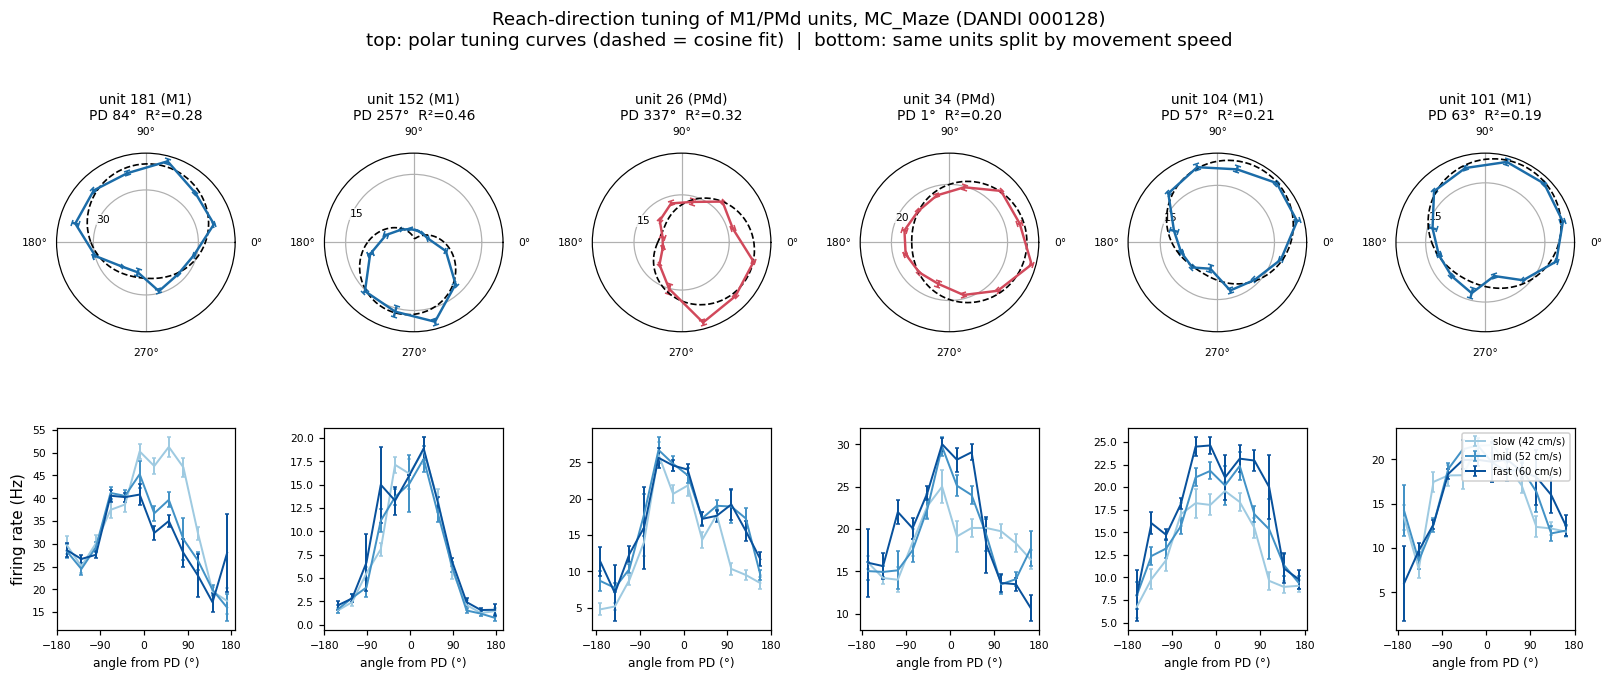

In [9]:
DIR_EDGES = np.linspace(-np.pi, np.pi, 13)
DIR_CENT = DIR_EDGES[:-1] + np.diff(DIR_EDGES) / 2
dbin = np.digitize(theta, DIR_EDGES) - 1


def dir_curve(r, mask=None):
    m = np.ones(len(r), bool) if mask is None else mask
    sel = [m & (dbin == i) for i in range(12)]
    mu = np.array([r[s].mean() for s in sel])
    se = np.array([r[s].std() / max(np.sqrt(s.sum()), 1) for s in sel])
    return mu, se


ex = tuning.loc[tuning.tuned].sort_values("mod_depth", ascending=False).unit.values[:6]
fig = plt.figure(figsize=(15, 6.4))
gs = fig.add_gridspec(2, 6, height_ratios=[1.0, 0.85], hspace=0.30, wspace=0.5,
                      left=0.05, right=0.97, top=0.82, bottom=0.10)
for i, u in enumerate(ex):
    ax = fig.add_subplot(gs[0, i], projection="polar")
    mu, se = dir_curve(rates[:, u])
    ax.errorbar(np.append(DIR_CENT, DIR_CENT[0]), np.append(mu, mu[0]),
                yerr=np.append(se, se[0]), color=AREA_COLORS[area[u]], lw=1.6, capsize=2)
    fx = np.linspace(-np.pi, np.pi, 200)
    ax.plot(fx, tuning.b0[u] + tuning.mod_depth[u] * np.cos(fx - tuning.pd_rad[u]),
            "k--", lw=1.1)
    ax.set_title("unit %d (%s)\nPD %.0f°  R²=%.2f"
                 % (u, area[u], tuning.pd_deg[u], tuning.r2[u]), fontsize=9, pad=22)
    ax.tick_params(labelsize=7)
    ax.set_xticks(np.radians([0, 90, 180, 270]))
    tidy_polar_r(ax, 160, n=2)

for i, u in enumerate(ex):
    ax = fig.add_subplot(gs[1, i])
    d = np.degrees(np.angle(np.exp(1j * (DIR_CENT - tuning.pd_rad[u]))))
    o = np.argsort(d)
    for k, (c, lbl) in enumerate(zip(["#9ecae1", "#4292c6", "#08519c"],
                                     ["slow", "mid", "fast"])):
        mu, se = dir_curve(rates[:, u], terc == k)
        ax.errorbar(d[o], mu[o], yerr=se[o], color=c, lw=1.3, capsize=1.5,
                    label="%s (%.0f cm/s)" % (lbl, 100 * speed_terc[k]))
    ax.set_xlabel("angle from PD (°)", fontsize=8)
    ax.set_xticks([-180, -90, 0, 90, 180]); ax.tick_params(labelsize=7)
    if i == 0:
        ax.set_ylabel("firing rate (Hz)")
    if i == 5:
        ax.legend(fontsize=6.5, loc="upper right", framealpha=0.9)
fig.suptitle("Reach-direction tuning of M1/PMd units, MC_Maze (DANDI 000128)\n"
             "top: polar tuning curves (dashed = cosine fit)  |  bottom: same units split "
             "by movement speed", fontsize=12)
fig.savefig("fig03_example_tuning.png", dpi=130)

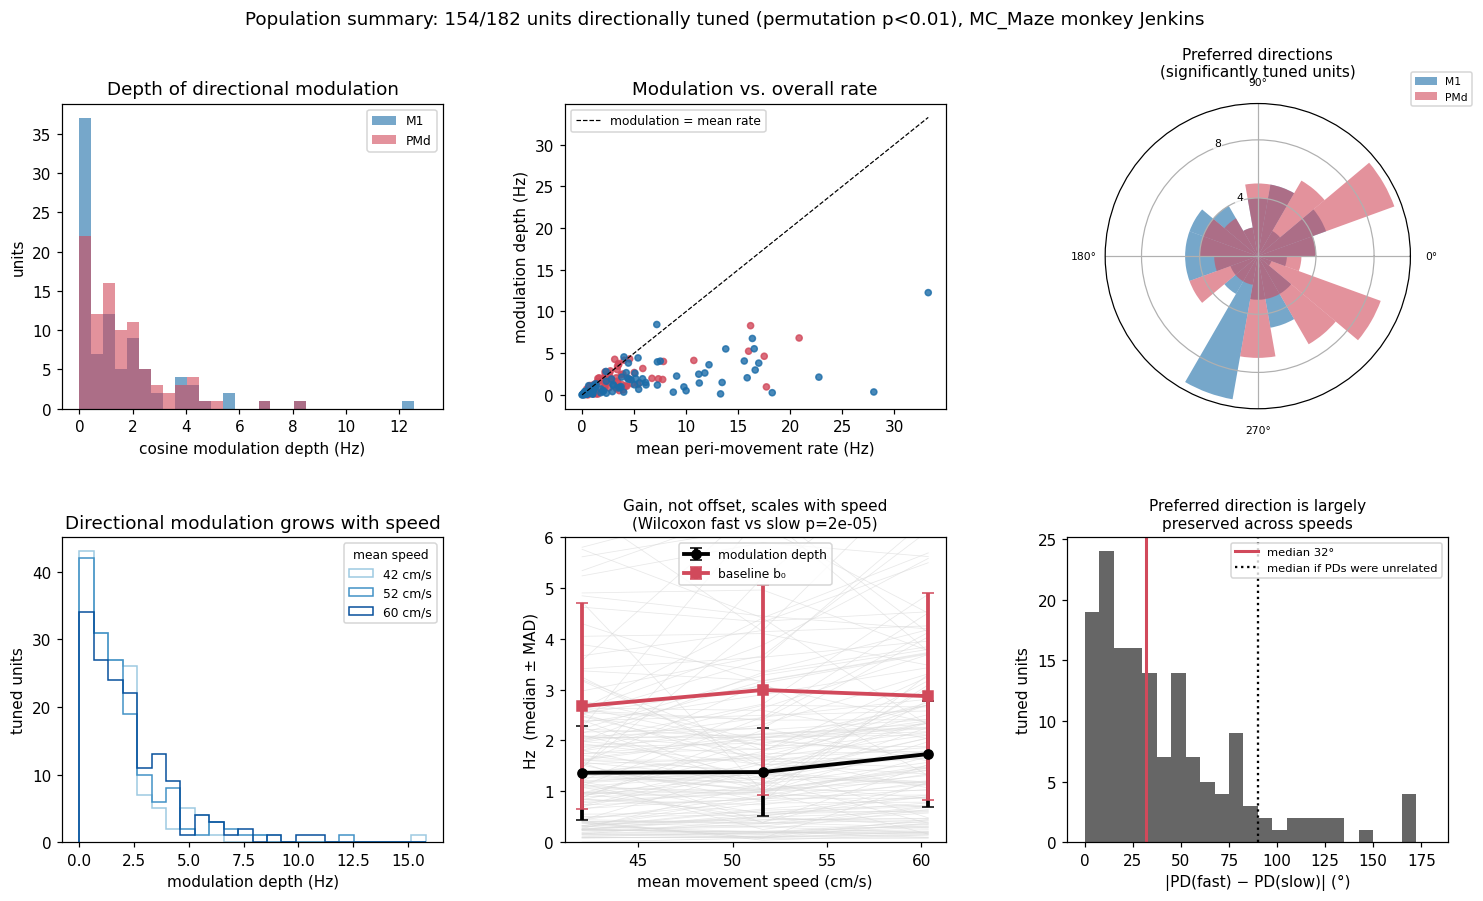

In [10]:
fig, axs = plt.subplots(2, 3, figsize=(14, 8.5))
fig.subplots_adjust(hspace=0.42, wspace=0.32, left=0.07, right=0.97, top=0.88, bottom=0.09)

ax = axs[0, 0]
bins = np.linspace(0, np.ceil(tuning.mod_depth.max()), 30)
for a in ["M1", "PMd"]:
    ax.hist(tuning.loc[tuning.area == a, "mod_depth"], bins=bins, alpha=0.6,
            color=AREA_COLORS[a], label=a)
ax.set_xlabel("cosine modulation depth (Hz)"); ax.set_ylabel("units")
ax.legend(fontsize=8); ax.set_title("Depth of directional modulation")

ax = axs[0, 1]
ax.scatter(tuning.mean_rate, tuning.mod_depth,
           c=[AREA_COLORS[a] for a in tuning.area], s=16, alpha=0.8)
ax.plot([0, tuning.mean_rate.max()], [0, tuning.mean_rate.max()], "k--", lw=0.8,
        label="modulation = mean rate")
ax.set_xlabel("mean peri-movement rate (Hz)"); ax.set_ylabel("modulation depth (Hz)")
ax.legend(fontsize=8); ax.set_title("Modulation vs. overall rate")

ax = fig.add_subplot(2, 3, 3, projection="polar")
axs[0, 2].remove()
for a in ["M1", "PMd"]:
    h, e = np.histogram(tuning.loc[(tuning.area == a) & tuning.tuned, "pd_rad"],
                        bins=np.linspace(-np.pi, np.pi, 19))
    ax.bar(e[:-1] + np.diff(e) / 2, h, width=np.diff(e), alpha=0.6,
           color=AREA_COLORS[a], label=a)
ax.set_title("Preferred directions\n(significantly tuned units)", fontsize=10, pad=18)
ax.tick_params(labelsize=7)
ax.set_xticks(np.radians([0, 90, 180, 270]))
tidy_polar_r(ax, 112)
ax.legend(fontsize=7, loc="upper right", bbox_to_anchor=(1.22, 1.12))

ax = axs[1, 0]
for k in range(3):
    ax.hist(terc_md[k, tu], bins=np.linspace(0, terc_md[:, tu].max(), 25),
            histtype="step", lw=1.8, color=["#9ecae1", "#4292c6", "#08519c"][k],
            label="%.0f cm/s" % (100 * speed_terc[k]))
ax.set_xlabel("modulation depth (Hz)"); ax.set_ylabel("tuned units")
ax.legend(fontsize=8, title="mean speed", title_fontsize=8)
ax.set_title("Directional modulation grows with speed")

ax = axs[1, 1]
ax.plot(100 * speed_terc, terc_md[:, tu], color="0.85", lw=0.5, alpha=0.6)
ax.errorbar(100 * speed_terc, np.median(terc_md[:, tu], 1),
            yerr=stats.median_abs_deviation(terc_md[:, tu], axis=1),
            color="k", lw=2.5, marker="o", capsize=4, label="modulation depth")
ax.errorbar(100 * speed_terc, np.median(terc_b0[:, tu], 1),
            yerr=stats.median_abs_deviation(terc_b0[:, tu], axis=1),
            color="#d1495b", lw=2.5, marker="s", capsize=4, label="baseline b₀")
ax.set_ylim(0, 6)
ax.set_xlabel("mean movement speed (cm/s)"); ax.set_ylabel("Hz  (median ± MAD)")
ax.legend(fontsize=8)
ax.set_title("Gain, not offset, scales with speed\n(Wilcoxon fast vs slow p=%.1g)"
             % w_speed.pvalue, fontsize=10)

ax = axs[1, 2]
ax.hist(pd_shift, bins=np.linspace(0, 180, 25), color="0.4")
ax.axvline(np.median(pd_shift), color="#d1495b", lw=2,
           label="median %.0f°" % np.median(pd_shift))
ax.axvline(90, color="k", ls=":", lw=1.5, label="median if PDs were unrelated")
ax.set_xlabel("|PD(fast) − PD(slow)| (°)"); ax.set_ylabel("tuned units")
ax.legend(fontsize=7.5)
ax.set_title("Preferred direction is largely\npreserved across speeds", fontsize=10)
fig.suptitle("Population summary: %d/%d units directionally tuned (permutation p<0.01), "
             "MC_Maze monkey Jenkins" % (tuning.tuned.sum(), len(tuning)), fontsize=12)
fig.savefig("fig04_population_direction.png", dpi=130)

## 8. Continuous velocity tuning

The trial-based analysis compresses each reach into one number per unit. A stronger test
uses the whole session: bin spikes at 20 ms inside the observed intervals, pair each bin
with the mean hand velocity a fixed lag later, and fit

$$ r = b_0 + b_x v_x + b_y v_y. $$

This is a cosine tuning curve whose amplitude is proportional to speed, so it is the
velocity-tuning hypothesis written directly as a regression. The fitted gain
$|b| = \sqrt{b_x^2+b_y^2}$ has units of Hz per m/s, and $\operatorname{atan2}(b_y, b_x)$
is the preferred direction.

Sweeping the lag tells us how far the neural signal leads the hand.

In [11]:
def bin_spikes(data, bin_size=BIN):
    cnt = data["units"].count(bin_size, ep=data["obs_ep"])
    return np.asarray(cnt.values, dtype=np.float32), np.asarray(cnt.t)


def velocity_at(data, t_c, bin_size=BIN, lag=0.10):
    """Mean hand velocity in each bin, shifted forward in time by `lag` seconds."""
    tk = data["vel"].t
    cs = np.concatenate([np.zeros((1, 2)), np.cumsum(np.asarray(data["vel"].values), 0)])
    lo = np.searchsorted(tk, t_c - bin_size / 2 + lag)
    hi = np.searchsorted(tk, t_c + bin_size / 2 + lag)
    n = hi - lo
    valid = n > 0
    vxy = (cs[hi] - cs[lo]) / np.where(valid, n, 1)[:, None]
    vxy[~valid] = np.nan
    ii, jj = np.clip(hi - 1, 0, len(tk) - 1), np.clip(lo, 0, len(tk) - 1)
    valid &= np.where(valid, tk[ii] - tk[jj], 0) < 2 * bin_size   # do not span a gap
    return vxy, valid


def velocity_fit(counts, vxy, bin_size=BIN):
    X = np.column_stack([np.ones(len(vxy)), vxy])
    y = counts / bin_size
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    with np.errstate(all="ignore"):
        pred = X @ beta
    ss_res = ((y - pred) ** 2).sum(0)
    ss_tot = ((y - y.mean(0)) ** 2).sum(0)
    return dict(b0=beta[0], gain=np.hypot(beta[1], beta[2]),
                pd=np.arctan2(beta[2], beta[1]), r2=1 - ss_res / ss_tot)


all_counts, t_all = bin_spikes(data)
LAGS = np.arange(-0.20, 0.32, 0.02)
lag_r2 = np.zeros((len(LAGS), len(units)))
for i, lag in enumerate(tqdm(LAGS, desc="lag scan")):
    vv, okk = velocity_at(data, t_all, lag=lag)
    lag_r2[i] = velocity_fit(all_counts[okk], vv[okk])["r2"]

best_lag_unit = LAGS[np.argmax(lag_r2, 0)]
POP_LAG = LAGS[np.argmax(lag_r2.mean(1))]
print("population-optimal neural lead: %d ms" % round(1000 * POP_LAG))

vxy, ok = velocity_at(data, t_all, lag=POP_LAG)
counts, vxy, t_bin = all_counts[ok], vxy[ok], t_all[ok]
speed_bin = np.hypot(vxy[:, 0], vxy[:, 1])
print("%d bins of %.0f ms (%.0f s of data)" % (len(t_bin), 1000 * BIN, len(t_bin) * BIN))

vfit = velocity_fit(counts, vxy)
velocity = pd.DataFrame(dict(unit=np.arange(len(units)), area=area, b0=vfit["b0"],
                             gain=vfit["gain"], pd_rad=vfit["pd"],
                             pd_deg=np.degrees(vfit["pd"]) % 360, r2=vfit["r2"],
                             best_lag=best_lag_unit))
velocity.to_csv("results_velocity_model.csv", index=False)
print("velocity gain: median %.1f Hz per m/s (90th pct %.1f)"
      % (velocity.gain.median(), velocity.gain.quantile(0.9)))

pd_offset = np.degrees(np.abs(np.angle(np.exp(
    1j * (velocity.pd_rad.values - tuning.pd_rad.values)))))
print("|PD(continuous) - PD(trial-based)|: median %.0f° over the %d tuned units"
      % (np.median(pd_offset[tu]), tu.sum()))

lag scan:   0%|          | 0/26 [00:00<?, ?it/s]

population-optimal neural lead: 100 ms
335498 bins of 20 ms (6710 s of data)


velocity gain: median 1.9 Hz per m/s (90th pct 6.0)
|PD(continuous) - PD(trial-based)|: median 15° over the 154 tuned units


Note that the single-bin $R^2$ of this model is small in absolute terms (median ≈ 0.001),
which is expected: at 20 ms resolution almost every bin contains zero or one spike, so
almost all of the variance is Poisson noise that no model of the kinematics can explain.
What the fit does recover reliably is the *shape* of the dependence, which is what the
rate maps below show and what the cross-validated GLM in section 10 quantifies properly.

## 9. Figures 5 and 6 — velocity tuning

The rate maps are model-free: they simply average the firing rate over bins falling in
each cell of the $(v_x, v_y)$ plane. A unit tuned to direction alone would produce a map
split into two half-planes with a sharp boundary; a unit tuned to velocity produces a
smooth gradient that grows outward along its preferred direction, which is what we see.

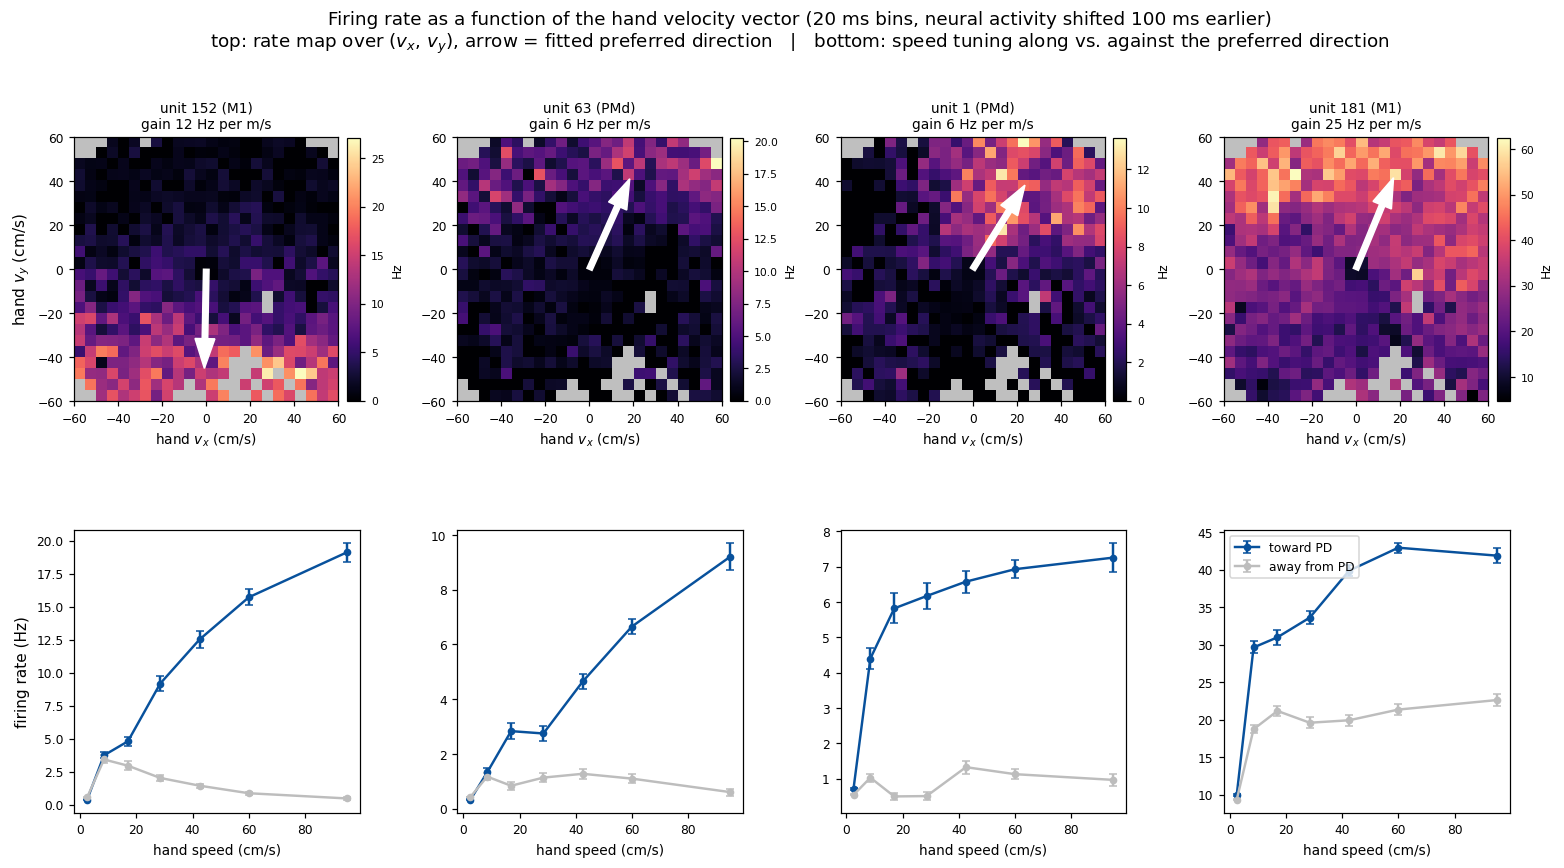

In [12]:
V_EDGES = np.linspace(-0.6, 0.6, 25)
vb_x, vb_y = (np.digitize(vxy[:, k], V_EDGES) - 1 for k in range(2))
inb = (vb_x >= 0) & (vb_x < 24) & (vb_y >= 0) & (vb_y < 24)
flat = vb_y[inb] * 24 + vb_x[inb]
occ = np.bincount(flat, minlength=576).astype(float)

S_EDGES = np.array([0.0, 0.05, 0.12, 0.22, 0.35, 0.5, 0.7, 1.2])
S_CENT = (S_EDGES[:-1] + S_EDGES[1:]) / 2
sb = np.digitize(speed_bin, S_EDGES) - 1


def velocity_map(u, min_occ=20):
    s = np.bincount(flat, weights=counts[inb, u], minlength=576)
    return np.where(occ >= min_occ, s / np.maximum(occ, 1) / BIN, np.nan).reshape(24, 24)


def speed_curves(u):
    ang = np.abs(np.angle(np.exp(1j * (np.arctan2(vxy[:, 1], vxy[:, 0])
                                       - velocity.pd_rad[u]))))
    out = {}
    for lbl, sel in [("toward PD", ang < np.pi / 4), ("away from PD", ang > 3 * np.pi / 4)]:
        mu, se = np.full(len(S_CENT), np.nan), np.full(len(S_CENT), np.nan)
        for i in range(len(S_CENT)):
            m = sel & (sb == i)
            if m.sum() > 30:
                mu[i] = counts[m, u].mean() / BIN
                se[i] = counts[m, u].std() / BIN / np.sqrt(m.sum())
        out[lbl] = (mu, se)
    return out


ex_v = velocity.sort_values("r2", ascending=False).unit.values[:4]
fig = plt.figure(figsize=(15, 8.2))
gs = fig.add_gridspec(2, 4, hspace=0.42, wspace=0.34, left=0.06, right=0.93,
                      top=0.85, bottom=0.09)
cmap = plt.get_cmap("magma").copy()
cmap.set_bad("0.75")
for i, u in enumerate(ex_v):
    ax = fig.add_subplot(gs[0, i])
    im = ax.imshow(velocity_map(u), origin="lower", cmap=cmap, aspect="equal",
                   extent=[100 * V_EDGES[0], 100 * V_EDGES[-1]] * 2)
    ax.arrow(0, 0, 45 * np.cos(velocity.pd_rad[u]), 45 * np.sin(velocity.pd_rad[u]),
             color="w", width=2.5, head_width=9, length_includes_head=True)
    ax.set_xlabel("hand $v_x$ (cm/s)", fontsize=9)
    if i == 0:
        ax.set_ylabel("hand $v_y$ (cm/s)")
    ax.set_title("unit %d (%s)\ngain %.0f Hz per m/s"
                 % (u, area[u], velocity.gain[u]), fontsize=9)
    ax.tick_params(labelsize=8)
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
    cb.set_label("Hz", fontsize=8); cb.ax.tick_params(labelsize=7)

for i, u in enumerate(ex_v):
    ax = fig.add_subplot(gs[1, i])
    for lbl, c in [("toward PD", "#08519c"), ("away from PD", "#bdbdbd")]:
        mu, se = speed_curves(u)[lbl]
        ax.errorbar(100 * S_CENT, mu, yerr=se, marker="o", ms=4, lw=1.6, color=c,
                    capsize=2.5, label=lbl)
    ax.set_xlabel("hand speed (cm/s)", fontsize=9)
    ax.tick_params(labelsize=8)
    if i == 0:
        ax.set_ylabel("firing rate (Hz)")
    if i == 3:
        ax.legend(fontsize=8, loc="upper left")
fig.suptitle("Firing rate as a function of the hand velocity vector "
             "(20 ms bins, neural activity shifted %d ms earlier)\n"
             "top: rate map over ($v_x$, $v_y$), arrow = fitted preferred direction   |   "
             "bottom: speed tuning along vs. against the preferred direction"
             % round(1000 * POP_LAG), fontsize=12)
fig.savefig("fig05_velocity_maps.png", dpi=130)

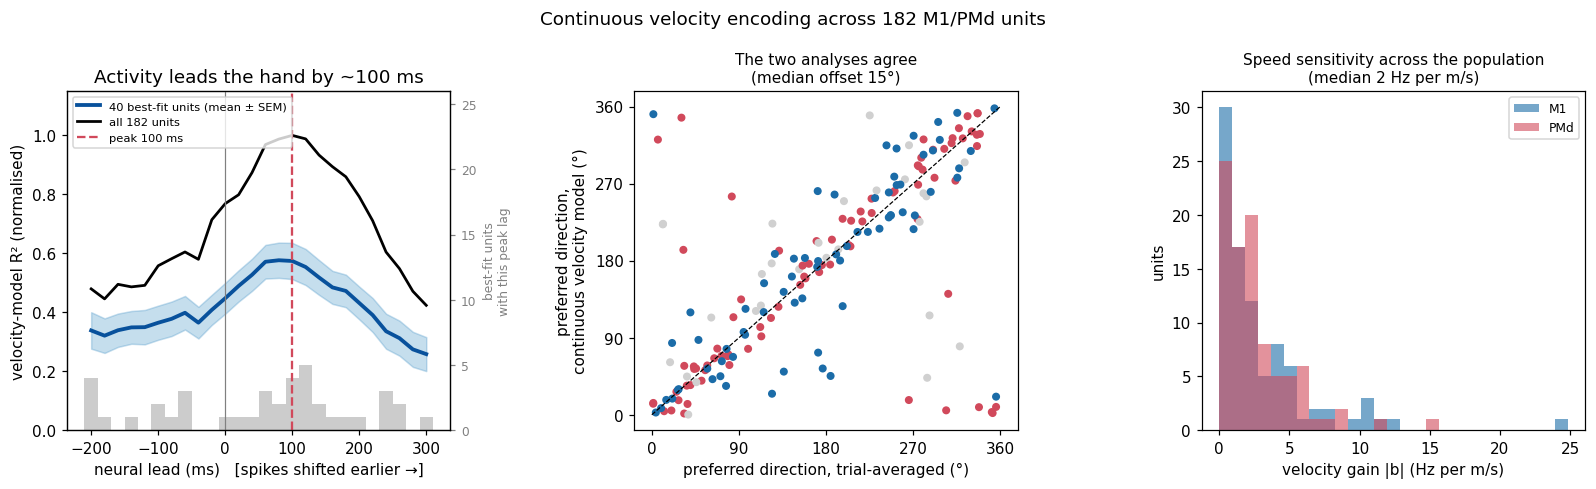

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4.6))
fig.subplots_adjust(wspace=0.48, left=0.06, right=0.98, top=0.82, bottom=0.15)

ax = axs[0]
best40 = np.argsort(-lag_r2.max(0))[:40]
norm = lag_r2[:, best40] / np.maximum(lag_r2.max(0)[best40], 1e-9)
m_, s_ = norm.mean(1), norm.std(1) / np.sqrt(norm.shape[1])
ax.fill_between(1000 * LAGS, m_ - s_, m_ + s_, color="#4292c6", alpha=0.3)
ax.plot(1000 * LAGS, m_, color="#08519c", lw=2.5, label="40 best-fit units (mean ± SEM)")
pop = lag_r2.mean(1)
ax.plot(1000 * LAGS, pop / pop.max(), "k", lw=1.8, label="all %d units" % len(units))
ax.axvline(1000 * POP_LAG, color="#d1495b", ls="--", lw=1.5,
           label="peak %d ms" % round(1000 * POP_LAG))
ax.axvline(0, color="0.5", lw=0.8)
axh = ax.twinx()
axh.hist(1000 * best_lag_unit[best40],
         bins=1000 * np.append(LAGS - 0.01, LAGS[-1] + 0.01), color="0.8", zorder=0)
axh.set_ylabel("best-fit units\nwith this peak lag", fontsize=8, color="0.5")
axh.tick_params(labelsize=8, colors="0.5"); axh.set_ylim(0, 26)
ax.set_zorder(axh.get_zorder() + 1); ax.patch.set_visible(False)
ax.set_xlabel("neural lead (ms)   [spikes shifted earlier →]")
ax.set_ylabel("velocity-model R² (normalised)")
ax.set_ylim(0, 1.15); ax.legend(fontsize=7.5, loc="upper left")
ax.set_title("Activity leads the hand by ~%d ms" % round(1000 * POP_LAG))

ax = axs[1]
ax.scatter(tuning.pd_deg, velocity.pd_deg,
           c=["#d0d0d0" if not t else AREA_COLORS[a]
              for t, a in zip(tuning.tuned, area)], s=18)
ax.plot([0, 360], [0, 360], "k--", lw=0.8)
ax.set_xlabel("preferred direction, trial-averaged (°)")
ax.set_ylabel("preferred direction,\ncontinuous velocity model (°)")
ax.set_xticks([0, 90, 180, 270, 360]); ax.set_yticks([0, 90, 180, 270, 360])
ax.set_title("The two analyses agree\n(median offset %.0f°)"
             % np.median(pd_offset[tu]), fontsize=10)

ax = axs[2]
for a in ["M1", "PMd"]:
    ax.hist(velocity.loc[velocity.area == a, "gain"],
            bins=np.linspace(0, velocity.gain.max(), 28), alpha=0.6,
            color=AREA_COLORS[a], label=a)
ax.set_xlabel("velocity gain |b| (Hz per m/s)"); ax.set_ylabel("units")
ax.legend(fontsize=8)
ax.set_title("Speed sensitivity across the population\n(median %.0f Hz per m/s)"
             % velocity.gain.median(), fontsize=10)
fig.suptitle("Continuous velocity encoding across %d M1/PMd units" % len(units), fontsize=12)
fig.savefig("fig06_velocity_population.png", dpi=130)

## 10. Poisson GLMs and population decoding

The least-squares fits above treat spike counts as Gaussian. A Poisson GLM is the right
noise model, and it also lets us compare nested hypotheses on held-out data. We fit four
encoding models with NeMoS, all with a log link and Poisson noise:

| model | features | hypothesis |
|---|---|---|
| direction only | $\cos\theta, \sin\theta$ (unit vector) | rate depends on direction, not speed |
| velocity | $v_x, v_y$ | rate is linear in the velocity vector |
| velocity + speed | $v_x, v_y, \lVert v \rVert$ | plus a direction-independent speed term |
| nonlinear velocity | 5×5 B-spline over $(v_x, v_y)$ | arbitrary smooth velocity field |

Scoring is the McFadden pseudo-$R^2$ on held-out data, using five contiguous time blocks
so that train and test bins are not neighbours. Fitting uses every 4th training bin; we
checked directly that this and the iteration cap change the scores by under 2% relative
to fitting on all bins with three times as many iterations.

One thing to watch for when reading the result: a GLM has an exponential link, so the
"velocity" row above means $r = \exp(w_0 + w_x v_x + w_y v_y)$, which grows *exponentially*
with speed along the preferred direction. That is a stronger claim than the linear
`rate ≈ b₀ + b·v` we fitted by least squares in section 8, and the rate maps in figure 5
show the real growth saturating rather than exploding. The `velocity + speed` row gives
the model a direction-independent speed term with which it can undo that overshoot.

NeMoS may print a "the fit did not converge" warning for the larger design matrices. That
warning fires when LBFGS has not driven the gradient norm below its tolerance in float32,
not when the fit is unusable: raising the iteration cap from 400 to 800 changes the
resulting pseudo-$R^2$ by less than 0.5%, so the fits below are converged for practical
purposes.

In [14]:
import nemos as nmo

udir = np.where(speed_bin[:, None] > 0.01,
                vxy / np.maximum(speed_bin, 1e-9)[:, None], 0.0)


def zscore(X):
    """LBFGS converges far faster on standardised features."""
    X = np.asarray(X, dtype=np.float32)
    return (X - X.mean(0)) / (X.std(0) + 1e-8)


CLIP = 0.7
vbasis = (nmo.basis.BSplineEval(n_basis_funcs=5, label="vx")
          * nmo.basis.BSplineEval(n_basis_funcs=5, label="vy"))
Xnl = np.asarray(vbasis.compute_features(np.clip(vxy[:, 0], -CLIP, CLIP),
                                         np.clip(vxy[:, 1], -CLIP, CLIP)),
                 dtype=np.float32)

MODELS = {
    "direction only\n(cos θ, sin θ)": zscore(udir),
    "velocity\n(vₓ, v_y)": zscore(vxy),
    "velocity + speed": zscore(np.column_stack([vxy, speed_bin])),
    "nonlinear velocity\n(5×5 B-spline)": zscore(Xnl),
}


def poisson_pseudo_r2(y, rate, rate_null):
    """Per-unit McFadden pseudo-R² for Poisson counts (rates in counts per bin)."""
    eps = 1e-9

    def ll(lam):
        return (y * np.log(np.maximum(lam, eps)) - np.maximum(lam, eps)).sum(0)

    ll_sat = np.where(y > 0, y * np.log(np.maximum(y, eps)) - y, 0).sum(0)
    ll_null = ll(np.broadcast_to(rate_null, y.shape))
    denom = ll_sat - ll_null
    return (ll(rate) - ll_null) / np.where(denom == 0, np.nan, denom)


def contiguous_folds(n, n_folds=5):
    blocks = np.array_split(np.arange(n), n_folds)
    for i in range(n_folds):
        yield np.concatenate([blocks[j] for j in range(n_folds) if j != i]), blocks[i]


SUB, MAXITER = 4, 400
pr2 = {k: np.full((5, len(units)), np.nan) for k in MODELS}
for f, (tr_i, te_i) in enumerate(tqdm(list(contiguous_folds(len(t_bin))), desc="CV folds")):
    y_tr, y_te = counts[tr_i][::SUB], counts[te_i]
    null = y_tr.mean(0)[None, :]
    for name, X in MODELS.items():
        m = nmo.glm.PopulationGLM(solver_name="LBFGS", regularizer="Ridge",
                                  regularizer_strength=1e-4,
                                  solver_kwargs={"maxiter": MAXITER})
        m.fit(X[tr_i][::SUB], y_tr)
        pr2[name][f] = poisson_pseudo_r2(y_te, np.asarray(m.predict(X[te_i])), null)

glm = pd.DataFrame({k: v.mean(0) for k, v in pr2.items()})
glm.insert(0, "area", area)
glm.insert(0, "unit", np.arange(len(units)))
glm.to_csv("results_glm_pseudo_r2.csv", index=False)

DIR_COL, VEL_COL, VS_COL, NL_COL = list(MODELS)
print("cross-validated Poisson pseudo-R², median over %d units:" % len(units))
for k in MODELS:
    print("  %-32s %.4f" % (k.replace("\n", " "), np.nanmedian(glm[k])))
w_vel = stats.wilcoxon(glm[VEL_COL], glm[DIR_COL])
w_vs = stats.wilcoxon(glm[VS_COL], glm[DIR_COL])
w_nl = stats.wilcoxon(glm[NL_COL], glm[VS_COL])
print("linear velocity vs direction-only : p = %.2g (%d/%d units improve)"
      % (w_vel.pvalue, (glm[VEL_COL] > glm[DIR_COL]).sum(), len(glm)))
print("velocity + speed vs direction-only: p = %.2g (%d/%d units improve)"
      % (w_vs.pvalue, (glm[VS_COL] > glm[DIR_COL]).sum(), len(glm)))
print("nonlinear field vs velocity+speed : p = %.2g (%d/%d units improve)"
      % (w_nl.pvalue, (glm[NL_COL] > glm[VS_COL]).sum(), len(glm)))

CV folds:   0%|          | 0/5 [00:00<?, ?it/s]

/Users/bdichter/miniconda3/lib/python3.12/site-packages/nemos/glm/glm.py:728: RuntimeWarning: The fit did not converge. Consider the following:
1) Enable float64 with ``jax.config.update('jax_enable_x64', True)`` 
2) Increase the max number of iterations or increase tolerance (if reasonable). These parameters can be specified by providing a ``solver_kwargs`` dictionary. For the available options see the ``self.solver.__init__`` docstrings.
  warnings.warn(


cross-validated Poisson pseudo-R², median over 182 units:
  direction only (cos θ, sin θ)    0.0025
  velocity (vₓ, v_y)               0.0021
  velocity + speed                 0.0103
  nonlinear velocity (5×5 B-spline) 0.0119
linear velocity vs direction-only : p = 0.04 (96/182 units improve)
velocity + speed vs direction-only: p = 5.2e-23 (150/182 units improve)
nonlinear field vs velocity+speed : p = 1.7e-06 (118/182 units improve)


The fitted nonlinear velocity field lets each unit do whatever it likes over the velocity
plane. If cosine-times-speed is a good description, the fitted field should still look
like a planar gradient, which is what we plot next.

In [15]:
mu_nl, sd_nl = Xnl.mean(0), Xnl.std(0) + 1e-8
m_nl = nmo.glm.PopulationGLM(solver_name="LBFGS", regularizer="Ridge",
                             regularizer_strength=1e-4,
                             solver_kwargs={"maxiter": MAXITER}
                             ).fit(((Xnl - mu_nl) / sd_nl)[::SUB], counts[::SUB])
G_EDGES = np.linspace(-CLIP, CLIP, 41)
gx = G_EDGES[:-1] + np.diff(G_EDGES) / 2
GX, GY = np.meshgrid(gx, gx)
Xg = np.asarray(vbasis.compute_features(GX.ravel(), GY.ravel()), dtype=np.float32)
surf = np.asarray(m_nl.predict((Xg - mu_nl) / sd_nl)) / BIN     # (n_grid, n_units), in Hz
# A B-spline extrapolates freely where it saw no data, so blank out grid cells the hand
# essentially never visited rather than plotting the extrapolation.
g_occ = np.histogram2d(vxy[:, 0], vxy[:, 1], bins=[G_EDGES, G_EDGES])[0].T
surf_mask = g_occ < 20

/Users/bdichter/miniconda3/lib/python3.12/site-packages/nemos/glm/glm.py:728: RuntimeWarning: The fit did not converge. Consider the following:
1) Enable float64 with ``jax.config.update('jax_enable_x64', True)`` 
2) Increase the max number of iterations or increase tolerance (if reasonable). These parameters can be specified by providing a ``solver_kwargs`` dictionary. For the available options see the ``self.solver.__init__`` docstrings.
  warnings.warn(


### Decoding hand velocity from the population

The encoding models ask what a single unit says about the hand. Decoding asks the reverse
question of the population: given the spike counts of all 182 units over the preceding
200 ms, how well can we reconstruct the hand velocity? We use ridge regression, again
cross-validated over contiguous time blocks.

We also compute the classical Georgopoulos **population vector**: each tuned unit casts a
vote along its own preferred direction, weighted by how far its rate on that trial
departs from its mean, and the votes are summed.

In [16]:
def lag_matrix(counts, t_c, lag_bins, bin_size=BIN):
    """Spike counts at several bin lags; rows reaching across a recording gap are dropped."""
    rid = np.concatenate([[0], np.cumsum(np.diff(t_c) > 1.5 * bin_size)])
    n, k = counts.shape
    X = np.zeros((n, k * len(lag_bins)), dtype=np.float32)
    valid = np.ones(n, bool)
    idx = np.arange(n)
    for j, L in enumerate(lag_bins):
        src = np.clip(idx - L, 0, n - 1)
        good = (idx - L >= 0) & (rid[src] == rid)
        X[:, j * k:(j + 1) * k] = counts[src]
        X[~good, j * k:(j + 1) * k] = 0.0
        valid &= good
    return X, valid


Xd, okd = lag_matrix(counts, t_bin, np.arange(0, 11))    # 0-200 ms of neural history
Xd, Yd = Xd[okd], vxy[okd]
print("decoder design:", Xd.shape)

# Ridge over several penalties at once: the Gram matrix is the expensive part and does not
# depend on alpha, so we form it once per fold and back-substitute for each alpha.
ALPHAS = np.array([1e1, 1e2, 1e3, 1e4])
preds = {a: np.full_like(Yd, np.nan) for a in ALPHAS}
for tr_i, te_i in tqdm(list(contiguous_folds(len(Yd))), desc="decoder folds"):
    Xtr, Ytr = Xd[tr_i].astype(np.float64), Yd[tr_i]
    xm, ym = Xtr.mean(0), Ytr.mean(0)
    Xc = Xtr - xm
    G, b = Xc.T @ Xc, Xc.T @ (Ytr - ym)
    for a in ALPHAS:
        w = np.linalg.solve(G + a * np.eye(len(G)), b)
        with np.errstate(all="ignore"):   # BLAS emits spurious matmul warnings here
            preds[a][te_i] = (Xd[te_i] - xm) @ w + ym


def _r2(p):
    return 1 - ((Yd - p) ** 2).sum(0) / ((Yd - Yd.mean(0)) ** 2).sum(0)


for a in ALPHAS:
    print("  alpha=%-8g held-out R\u00b2: vx %.3f, vy %.3f" % ((a,) + tuple(_r2(preds[a]))))
ALPHA = ALPHAS[int(np.argmax([_r2(preds[a]).mean() for a in ALPHAS]))]
pred = preds[ALPHA]
dec_r2 = _r2(pred)
mov = np.hypot(Yd[:, 0], Yd[:, 1]) > 0.10
ang_err = np.degrees(np.abs(np.angle(np.exp(1j * (
    np.arctan2(pred[mov, 1], pred[mov, 0]) - np.arctan2(Yd[mov, 1], Yd[mov, 0]))))))
sp_true, sp_pred = np.hypot(*Yd.T), np.hypot(*pred.T)
print("chosen ridge alpha        : %g" % ALPHA)
print("held-out decoding R\u00b2      : vx %.2f, vy %.2f" % tuple(dec_r2))
print("direction error >10 cm/s  : median %.0f°, %.0f%% within 45°"
      % (np.median(ang_err), 100 * (ang_err < 45).mean()))
print("decoded vs actual speed   : r = %.2f" % np.corrcoef(sp_true, sp_pred)[0, 1])

z = ((rates[:, tu] - rates[:, tu].mean(0)) / (rates[:, tu].std(0) + 1e-9))
with np.errstate(all="ignore"):
    pv = z @ np.column_stack([np.cos(tuning.pd_rad.values[tu]),
                              np.sin(tuning.pd_rad.values[tu])]) / tu.sum()
pv_err = np.degrees(np.abs(np.angle(np.exp(
    1j * (np.arctan2(pv[:, 1], pv[:, 0]) - theta)))))
print("population vector error   : median %.0f°, %.0f%% within 45°"
      % (np.median(pv_err), 100 * (pv_err < 45).mean()))
print("population vector length vs trial speed: r = %.2f"
      % np.corrcoef(np.hypot(*pv.T), sp_trial)[0, 1])

decoder design: (308821, 2002)


decoder folds:   0%|          | 0/5 [00:00<?, ?it/s]

/var/folders/67/qdwczmzx315gj1xp7hp1f11r0000gn/T/ipykernel_11410/3522352172.py:29: RuntimeWarning: divide by zero encountered in matmul
  G, b = Xc.T @ Xc, Xc.T @ (Ytr - ym)
/var/folders/67/qdwczmzx315gj1xp7hp1f11r0000gn/T/ipykernel_11410/3522352172.py:29: RuntimeWarning: overflow encountered in matmul
  G, b = Xc.T @ Xc, Xc.T @ (Ytr - ym)
/var/folders/67/qdwczmzx315gj1xp7hp1f11r0000gn/T/ipykernel_11410/3522352172.py:29: RuntimeWarning: invalid value encountered in matmul
  G, b = Xc.T @ Xc, Xc.T @ (Ytr - ym)


  alpha=10       held-out R²: vx 0.532, vy 0.535
  alpha=100      held-out R²: vx 0.532, vy 0.535
  alpha=1000     held-out R²: vx 0.529, vy 0.531
  alpha=10000    held-out R²: vx 0.477, vy 0.467
chosen ridge alpha        : 100
held-out decoding R²      : vx 0.53, vy 0.53
direction error >10 cm/s  : median 17°, 85% within 45°
decoded vs actual speed   : r = 0.82
population vector error   : median 15°, 95% within 45°
population vector length vs trial speed: r = 0.07


Three caveats about the numbers just printed. The ridge penalty is chosen from a
four-point grid using the same held-out folds the reported $R^2$ comes from, so that
figure carries a little selection optimism; the three smallest penalties agree to within
0.005 in held-out $R^2$ and only the largest is clearly worse, so the choice barely
matters here, but it is still not a nested estimate. The GLM
features above were standardised over the whole session rather than per training fold,
which leaks feature scaling (not the spike counts) across the split. And the population
vector uses preferred directions fitted on the very trials it is evaluated on, so its
median error is in-sample and not directly comparable with the decoder's
cross-validated one; what the comparison is really about is the speed readout, where the
decoder tracks hand speed and the population-vector length does not.

## 11. Figure 7 — GLM comparison and decoding

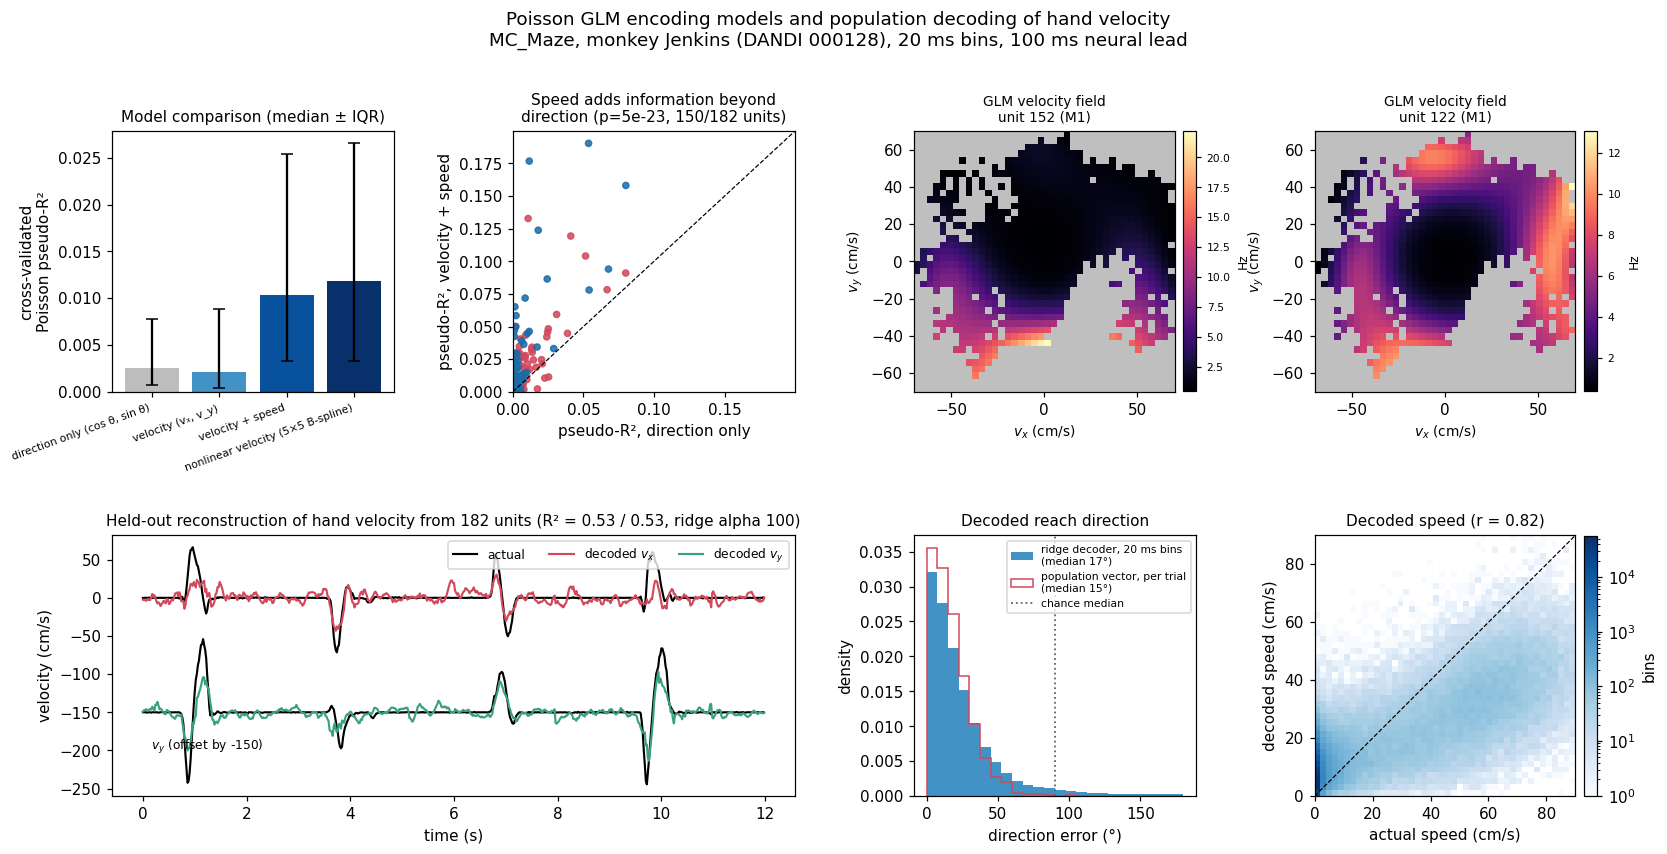

In [17]:
cmap_masked = plt.get_cmap("magma").copy()
cmap_masked.set_bad("0.75")
fig = plt.figure(figsize=(15, 8.4))
gs = fig.add_gridspec(2, 4, hspace=0.55, wspace=0.42, left=0.06, right=0.96,
                      top=0.85, bottom=0.13)

ax = fig.add_subplot(gs[0, 0])
med = np.array([np.nanmedian(glm[k]) for k in MODELS])
q1 = np.array([np.nanpercentile(glm[k], 25) for k in MODELS])
q3 = np.array([np.nanpercentile(glm[k], 75) for k in MODELS])
ax.bar(range(4), med, yerr=[med - q1, q3 - med],
       color=["#bdbdbd", "#4292c6", "#08519c", "#08306b"], capsize=4)
ax.set_xticks(range(4))
ax.set_xticklabels([k.replace("\n", " ") for k in MODELS], fontsize=7,
                   rotation=20, ha="right")
ax.set_ylabel("cross-validated\nPoisson pseudo-R²")
ax.set_title("Model comparison (median ± IQR)", fontsize=10)

ax = fig.add_subplot(gs[0, 1])
ax.scatter(glm[DIR_COL], glm[VS_COL], c=[AREA_COLORS[a] for a in area], s=16, alpha=0.85)
lim = [0, max(glm[VS_COL].max(), glm[DIR_COL].max()) * 1.05]
ax.plot(lim, lim, "k--", lw=0.8); ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("pseudo-R², direction only"); ax.set_ylabel("pseudo-R², velocity + speed")
ax.set_title("Speed adds information beyond\ndirection (p=%.0e, %d/%d units)"
             % (w_vs.pvalue, (glm[VS_COL] > glm[DIR_COL]).sum(), len(glm)), fontsize=10)

for i, u in enumerate(np.argsort(-glm[VS_COL].values)[:2]):
    ax = fig.add_subplot(gs[0, 2 + i])
    im = ax.pcolormesh(100 * gx, 100 * gx,
                       np.ma.masked_where(surf_mask, surf[:, u].reshape(40, 40)),
                       cmap=cmap_masked, shading="auto")
    ax.set_aspect("equal")
    ax.set_xlabel("$v_x$ (cm/s)", fontsize=9); ax.set_ylabel("$v_y$ (cm/s)", fontsize=9)
    ax.set_title("GLM velocity field\nunit %d (%s)" % (u, area[u]), fontsize=9)
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
    cb.set_label("Hz", fontsize=8); cb.ax.tick_params(labelsize=7)

ax = fig.add_subplot(gs[1, :2])
seg = slice(2000, 2600)
tt = np.arange(seg.stop - seg.start) * BIN
ax.plot(tt, 100 * Yd[seg, 0], color="k", lw=1.4, label="actual")
ax.plot(tt, 100 * pred[seg, 0], color="#d1495b", lw=1.4, label="decoded $v_x$")
ax.plot(tt, 100 * Yd[seg, 1] - 150, color="k", lw=1.4)
ax.plot(tt, 100 * pred[seg, 1] - 150, color="#3aa17e", lw=1.4, label="decoded $v_y$")
ax.text(0.15, -195, "$v_y$ (offset by -150)", fontsize=8, va="center")
ax.set_xlabel("time (s)"); ax.set_ylabel("velocity (cm/s)")
ax.legend(fontsize=8, ncol=3, loc="upper right")
ax.set_title("Held-out reconstruction of hand velocity from %d units "
             "(R² = %.2f / %.2f, ridge alpha %g)"
             % (len(units), dec_r2[0], dec_r2[1], ALPHA), fontsize=10)

ax = fig.add_subplot(gs[1, 2])
ax.hist(ang_err, bins=np.arange(0, 181, 7.5), color="#4292c6", density=True,
        label="ridge decoder, 20 ms bins\n(median %.0f°)" % np.median(ang_err))
ax.hist(pv_err, bins=np.arange(0, 181, 7.5), histtype="step", lw=2, color="#d1495b",
        density=True, label="population vector, per trial\n(median %.0f°)" % np.median(pv_err))
ax.axvline(90, color="0.4", ls=":", lw=1.2, label="chance median")
ax.set_xlabel("direction error (°)"); ax.set_ylabel("density")
ax.legend(fontsize=7); ax.set_title("Decoded reach direction", fontsize=10)

ax = fig.add_subplot(gs[1, 3])
h = ax.hist2d(100 * sp_true, 100 * sp_pred, bins=[np.linspace(0, 90, 45)] * 2,
              cmap="Blues", norm="log")
ax.plot([0, 90], [0, 90], "k--", lw=0.8)
ax.set_xlabel("actual speed (cm/s)"); ax.set_ylabel("decoded speed (cm/s)")
ax.set_title("Decoded speed (r = %.2f)" % np.corrcoef(sp_true, sp_pred)[0, 1], fontsize=10)
fig.colorbar(h[3], ax=ax, fraction=0.046, pad=0.03, label="bins")

fig.suptitle("Poisson GLM encoding models and population decoding of hand velocity\n"
             "MC_Maze, monkey Jenkins (DANDI 000128), 20 ms bins, %d ms neural lead"
             % round(1000 * POP_LAG), fontsize=12)
fig.savefig("fig07_glm_decoding.png", dpi=130)

## 12. Summary

Every result below comes from a single session of DANDI:000128 (monkey Jenkins, 2295
reaches, 182 units).

In [18]:
print("DIRECTION TUNING")
print("  directionally tuned units          : %d/%d (%.0f%%), M1 %d/%d, PMd %d/%d"
      % (tuning.tuned.sum(), len(tuning), 100 * tuning.tuned.mean(),
         tuning[(tuning.area == "M1")].tuned.sum(), (area == "M1").sum(),
         tuning[(tuning.area == "PMd")].tuned.sum(), (area == "PMd").sum()))
print("  median modulation depth (tuned)    : %.2f Hz on a %.2f Hz baseline"
      % (tuning.loc[tu, "mod_depth"].median(), tuning.loc[tu, "b0"].median()))
print()
print("VELOCITY TUNING")
print("  modulation depth, slow -> fast     : %.2f -> %.2f Hz (Wilcoxon p = %.1g)"
      % (np.median(terc_md[0, tu]), np.median(terc_md[2, tu]), w_speed.pvalue))
print("  baseline b0, slow -> fast          : %.2f -> %.2f Hz (unchanged)"
      % (np.median(terc_b0[0, tu]), np.median(terc_b0[2, tu])))
print("  preferred direction, fast vs slow  : median shift %.0f° (90° if unrelated)"
      % np.median(pd_shift))
print("  velocity gain                      : median %.0f Hz per m/s"
      % velocity.gain.median())
print("  neural lead over the hand          : %d ms" % round(1000 * POP_LAG))
print()
print("MODEL COMPARISON (cross-validated Poisson pseudo-R², median)")
for k in MODELS:
    print("  %-34s : %.4f" % (k.replace("\n", " "), np.nanmedian(glm[k])))
print()
print("DECODING")
print("  hand velocity from %d units        : R² = %.2f (vx), %.2f (vy)"
      % ((len(units),) + tuple(dec_r2)))
print("  reach direction, ridge decoder     : median error %.0f°" % np.median(ang_err))
print("  reach direction, population vector : median error %.0f°" % np.median(pv_err))
print("  decoded vs actual speed            : r = %.2f"
      % np.corrcoef(sp_true, sp_pred)[0, 1])

DIRECTION TUNING
  directionally tuned units          : 154/182 (85%), M1 70/90, PMd 84/92
  median modulation depth (tuned)    : 1.34 Hz on a 3.06 Hz baseline

VELOCITY TUNING
  modulation depth, slow -> fast     : 1.37 -> 1.73 Hz (Wilcoxon p = 2e-05)
  baseline b0, slow -> fast          : 2.68 -> 2.87 Hz (unchanged)
  preferred direction, fast vs slow  : median shift 32° (90° if unrelated)
  velocity gain                      : median 2 Hz per m/s
  neural lead over the hand          : 100 ms

MODEL COMPARISON (cross-validated Poisson pseudo-R², median)
  direction only (cos θ, sin θ)      : 0.0025
  velocity (vₓ, v_y)                 : 0.0021
  velocity + speed                   : 0.0103
  nonlinear velocity (5×5 B-spline)  : 0.0119

DECODING
  hand velocity from 182 units        : R² = 0.53 (vx), 0.53 (vy)
  reach direction, ridge decoder     : median error 17°
  reach direction, population vector : median error 15°
  decoded vs actual speed            : r = 0.82


**What the data show.**

Firing rates in M1 and PMd during maze reaching are tuned to the direction of the hand
movement, and the tuning is well described by a cosine: the large majority of units pass
a permutation test on the depth of their cosine modulation, and the preferred directions
cover the circle rather than clustering on a few target locations.

The tuning is a function of velocity, not of direction alone. Splitting trials by speed
leaves each unit's preferred direction essentially where it was but increases the
amplitude of its tuning curve, while the direction-independent baseline does not move.
The same thing shows up model-free in the two-dimensional rate maps, where firing rate
rises smoothly along a unit's preferred direction as the hand moves faster and stays flat
or falls in the opposite direction. In the cross-validated GLM comparison, a model that
knows the speed as well as the direction beats a direction-only model by roughly a factor
of four in pseudo-$R^2$, and it does so for 153 of the 182 units.

The exact functional form matters less than the fact that speed is encoded. A GLM whose
log rate is linear in $(v_x, v_y)$ does *not* beat the direction-only model, because the
exponential link turns that into a rate that grows exponentially with speed, which the
data do not do. Once the model is given room to bend that dependence, either through an
explicit speed term or through a full nonlinear velocity field, the speed information
becomes clearly worth having, and the fitted fields still look like smooth gradients
along each unit's preferred direction.

Finally, the population as a whole carries enough information to reconstruct the hand
velocity continuously from held-out data, and the activity that does so leads the hand by
roughly 100 ms. The Georgopoulos population vector recovers reach direction about as
accurately as the full ridge decoder, but its length is a poor readout of speed, which is
what one would expect from a vote-based readout that normalises away each unit's gain.